In [1]:
import warnings
warnings.filterwarnings("ignore")  # Ignore all warnings

import numpy as np
import matplotlib.pyplot as plt
from agentic_energy.heuristics.heuristic_trader import HeuristicTrader, records_to_arrays
from agentic_energy.data_loader import EnergyDataLoader, BatteryDataLoader
from agentic_energy.schemas import BatteryParams, DayInputs, SolveRequest

[04/12/26 03:01:41] INFO     HTTP Request: GET                                                      ]8;id=925420;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=133;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             https://raw.githubusercontent.com/BerriAI/litellm/main/model_prices_an                
                             d_context_window.json "HTTP/1.1 200 OK"                                               

Available LLM providers: ['gemini', 'openai', 'ollama']


In [2]:
REGION="ERCOT"
YEAR=2022
data_version = "forecast"
forecast_type = "RF"
duration_hours=4
capacity=43.13
soc_init=0.5
soc_min=0.0
soc_max=1.0
eta_c = 0.95
eta_d = 0.95
soc_target=0.5
start_date=f"{YEAR}-01-01"
end_date=f"{YEAR}-12-31"

In [3]:
italy_forecast_obj = EnergyDataLoader(region = REGION, data_version=data_version, forecast_type=forecast_type)
italy_forecast_data = italy_forecast_obj.load_region_data()
italy_forecast = await italy_forecast_obj.get_filtered_data(start_date, end_date)

2026-04-12 03:01:42.371 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Ercot_data_forecast_RF.csv


In [4]:
italy_obj = EnergyDataLoader(region=REGION, data_version = "actual")
italy_data = italy_obj.load_region_data()
italy_data = await italy_obj.get_filtered_data(start_date=start_date, end_date=end_date)

2026-04-12 03:01:42.769 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Ercot_energy_data.csv


In [5]:
stats= await EnergyDataLoader.get_summary_stats_from_ag(italy_data)
print(stats.pretty_print())

aType : <class 'agentic_energy.schemas.SummaryStats'>
region: ERCOT
total_records: 8734
date_range:
  start: '2022-01-01 00:00:00'
  end: '2022-12-31 23:00:00'
prices:
  count: 8734
  min: 1.55
  max: 2535.74
  avg: 64.15200480879322
  median: 48.055
  p25: 33.995000000000005
  p75: 68.7275
  std: 88.61357422451728
  var: 7852.365536844033
consumption:
  count: 8734
  min: 31796.35394
  max: 80037.836007
  avg: 49038.9610778697
  median: 46453.162656
  p25: 41310.25119075
  p75: 54585.50193725
  std: 10477.435415539767
  var: 109776652.88680696


aType : <class 'agentic_energy.schemas.SummaryStats'>
region: ERCOT
total_records: 8734
date_range:
  start: '2022-01-01 00:00:00'
  end: '2022-12-31 23:00:00'
prices:
  count: 8734
  min: 1.55
  max: 2535.74
  avg: 64.15200480879322
  median: 48.055
  p25: 33.995000000000005
  p75: 68.7275
  std: 88.61357422451728
  var: 7852.365536844033
consumption:
  count: 8734
  min: 31796.35394
  max: 80037.836007
  avg: 49038.9610778697
  median: 46453

In [6]:
batterydetails=BatteryParams(
    capacity_MWh=capacity,
    cmax_MW=capacity/duration_hours,
    dmax_MW=capacity/duration_hours,
    soc_init=soc_init,
    soc_min=soc_min,
    soc_max=soc_max,
    eta_c=eta_c,
    eta_d=eta_d,
    soc_target=soc_target,
)
batterydetails

BatteryParams(capacity_MWh=43.13, soc_init=0.5, soc_min=0.0, soc_max=1.0, cmax_MW=10.7825, dmax_MW=10.7825, eta_c=0.95, eta_d=0.95, soc_target=0.5)

In [7]:
trader_time = HeuristicTrader(
        mode="time",
        charge_windows=[(2, 6), (10, 16), (20, 22)],
        discharge_windows=[(0, 2), (6, 10), (16, 20), (22, 24)],
    )
trader_quant = HeuristicTrader(
        mode="quantile",
        low_q=0.30,
        high_q=0.70,
    )

In [8]:
results_time = []
day_info_time = []
decision_list_time = []
soc_list_time = []
num_days = len(italy_data) // 24
bat_time = batterydetails.copy(deep=True)
for i in range(num_days):
        print(f"[TIME] Solving day {i+1}/{num_days}")
        # day_records = italy_data[i * 24 : (i + 1) * 24]
        # prices, demand = records_to_arrays(day_records)

        forecast_prices, forecast_demand = records_to_arrays(italy_forecast_data[i*24:(i+1)*24])
        actual_prices, actual_demand = records_to_arrays(italy_data[i*24:(i+1)*24])

        day = DayInputs(
            prices_buy=actual_prices,
            prices_sell=actual_prices,
            demand_MW=actual_demand,
            allow_export=True,
            dt_hours=1.0,
            prices_buy_forecast=forecast_prices,
            prices_sell_forecast=forecast_prices,
            demand_MW_forecast=forecast_demand,
        )

        day_info_time.append(day)

        req=SolveRequest(
            battery=bat_time,
            day = day,
            solver = None,
            solver_opts={"mode": "time"},
        )

        result = trader_time.solve(req)
        results_time.append(result)

        # Stitch SoC: use last SoC (fractional) from the day as next day's init
        if result.soc and len(result.soc) > 0:
            # Avoid duplicating the last point in per-step ladders
            soc_list_time += result.soc[:-1]
            # bat_time.soc_init = float(result.soc[-1])
        else:
            # If solver returned empty SoC (shouldn't happen), keep previous init
            pass

        # Accumulate decisions
        if result.decision:
            decision_list_time += result.decision

        # Optional: show day summary
        print(f"  Objective cost (day {i+1}): {result.objective_cost:.4f}")

total_cost_time = float(np.nansum([r.objective_cost for r in results_time]))
print(f"=== TIME windows summary ===")
print(f"Total objective cost over all days: {total_cost_time:.4f}  (negative = profit)")

[TIME] Solving day 1/363
  Objective cost (day 1): 20568869.0765
[TIME] Solving day 2/363
  Objective cost (day 2): 593212023.3107
[TIME] Solving day 3/363
  Objective cost (day 3): 134352773.5192
[TIME] Solving day 4/363
  Objective cost (day 4): 22124158.3195
[TIME] Solving day 5/363
  Objective cost (day 5): 18539767.1199
[TIME] Solving day 6/363
  Objective cost (day 6): 21680311.4396
[TIME] Solving day 7/363
  Objective cost (day 7): 206587285.0859
[TIME] Solving day 8/363
  Objective cost (day 8): 24580984.3726
[TIME] Solving day 9/363
  Objective cost (day 9): 17500483.0983
[TIME] Solving day 10/363
  Objective cost (day 10): 21686114.3330
[TIME] Solving day 11/363
  Objective cost (day 11): 22749198.3482
[TIME] Solving day 12/363
  Objective cost (day 12): 20496602.2270
[TIME] Solving day 13/363
  Objective cost (day 13): 19218910.0188
[TIME] Solving day 14/363
  Objective cost (day 14): 18111893.1576
[TIME] Solving day 15/363
  Objective cost (day 15): 20136952.4024
[TIME] Sol

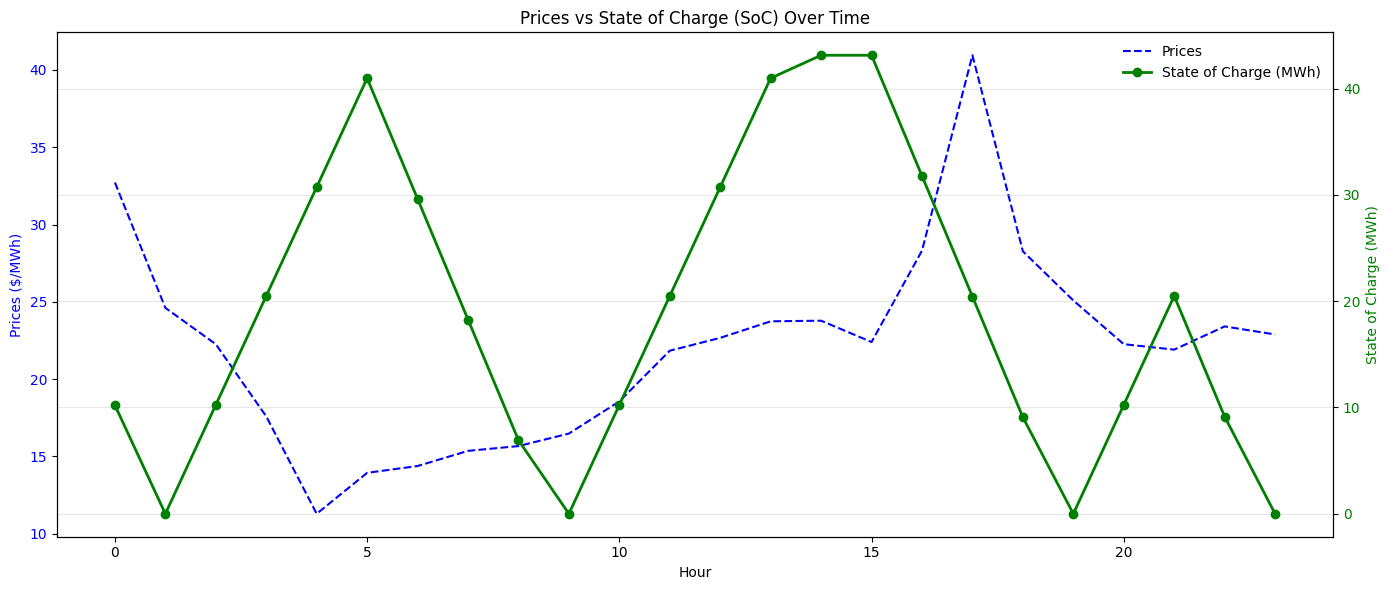

In [9]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Primary axis (Prices) ---
ax1.plot(hours, day_info_time[0].prices_buy, '--b', label='Prices')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Prices ($/MWh)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# --- Secondary axis (State of Charge) ---
ax2 = ax1.twinx()
ax2.plot(hours, np.array(results_time[0].soc[1:]) * bat_time.capacity_MWh,
         '-og', label='State of Charge (MWh)', linewidth=2, markersize=6)
ax2.set_ylabel('State of Charge (MWh)', color='g')
ax2.tick_params(axis='y', labelcolor='g')


# --- Legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best', frameon=False)

plt.title('Prices vs State of Charge (SoC) Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


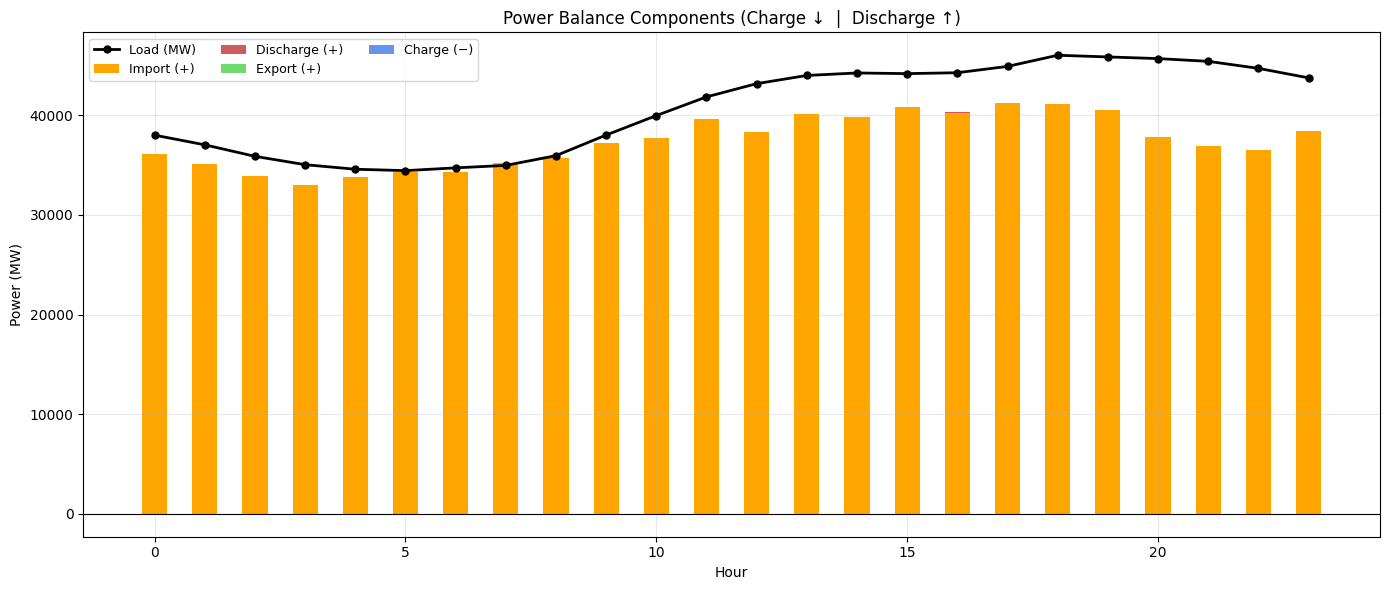

In [10]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)

# Data arrays
load = np.array(day_info_time[0].demand_MW)
charge = np.array(results_time[0].charge_MW)
discharge = np.array(results_time[0].discharge_MW)
import_MW = np.array(results_time[0].import_MW)
export_MW = np.array(results_time[0].export_MW) if getattr(day_info_time[0], "allow_export", False) else np.zeros_like(load)

# Flip battery convention for visualization
charge_vis = -charge       # show charge below 0
discharge_vis = discharge  # show discharge above 0

# ---------------------- PLOT ----------------------
fig, ax = plt.subplots(figsize=(14, 6))

# --- positive side stacking (Import + Discharge + Export) ---
# import is base layer
ax.bar(hours, import_MW, width=0.5, color='orange', label='Import (+)')
# discharge stacked on top of import
ax.bar(hours, discharge_vis, width=0.5, bottom=import_MW, color='indianred', label='Discharge (+)')
# export stacked on top (for clear separation)
ax.bar(hours, export_MW, width=0.5, bottom=import_MW + discharge_vis, color='limegreen', alpha=0.7, label='Export (+)')

# --- negative side stacking (Charge only) ---
ax.bar(hours, charge_vis, width=0.5, color='cornflowerblue', label='Charge (−)')

# --- Load as line ---
ax.plot(hours, load, '-ok', linewidth=2, markersize=5, label='Load (MW)')

# Formatting
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Power (MW)")
ax.set_xlabel("Hour")
ax.set_title("Power Balance Components (Charge ↓  |  Discharge ↑)")
ax.legend(ncol=3, loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
results_quantile = []
day_info_quantile = []
decision_list_quantile = []
soc_list_quantile = []
num_days = len(italy_data) // 24
bat_quantile = batterydetails.copy(deep=True)
for i in range(num_days):
        print(f"[TIME] Solving day {i+1}/{num_days}")
        forecast_prices, forecast_demand = records_to_arrays(italy_forecast_data[i*24:(i+1)*24])
        actual_prices, actual_demand = records_to_arrays(italy_data[i*24:(i+1)*24])

        day = DayInputs(
            prices_buy=actual_prices,
            prices_sell=actual_prices,
            demand_MW=actual_demand,
            allow_export=True,
            dt_hours=1.0,
            prices_buy_forecast=forecast_prices,
            prices_sell_forecast=forecast_prices,
            demand_MW_forecast=forecast_demand,
        )

        day_info_quantile.append(day)

        req=SolveRequest(
            battery=bat_quantile,
            day = day,
            solver = None,
            solver_opts={"mode": "quantile"},
        )

        result = trader_quant.solve(req)
        results_quantile.append(result)

        # Stitch SoC: use last SoC (fractional) from the day as next day's init
        if result.soc and len(result.soc) > 0:
            # Avoid duplicating the last point in per-step ladders
            soc_list_quantile += result.soc[:-1]
            # bat_quantile.soc_init = float(result.soc[-1])
        else:
            # If solver returned empty SoC (shouldn't happen), keep previous init
            pass

        # Accumulate decisions
        if result.decision:
            decision_list_quantile += result.decision

        # Optional: show day summary
        print(f"  Objective cost (day {i+1}): {result.objective_cost:.4f}")

total_cost_quantile = float(np.nansum([r.objective_cost for r in results_quantile]))
print(f"=== Quantile windows summary ===")
print(f"Total objective cost over all days: {total_cost_quantile:.4f}  (negative = profit)")

[TIME] Solving day 1/363
  Objective cost (day 1): 20568936.9515
[TIME] Solving day 2/363
  Objective cost (day 2): 593194959.6495
[TIME] Solving day 3/363
  Objective cost (day 3): 134316824.5003
[TIME] Solving day 4/363
  Objective cost (day 4): 22124350.3123
[TIME] Solving day 5/363
  Objective cost (day 5): 18539888.3258
[TIME] Solving day 6/363
  Objective cost (day 6): 21679985.7737
[TIME] Solving day 7/363
  Objective cost (day 7): 206563728.8631
[TIME] Solving day 8/363
  Objective cost (day 8): 24580418.9134
[TIME] Solving day 9/363
  Objective cost (day 9): 17500458.1418
[TIME] Solving day 10/363
  Objective cost (day 10): 21685759.1854
[TIME] Solving day 11/363
  Objective cost (day 11): 22749362.8267
[TIME] Solving day 12/363
  Objective cost (day 12): 20496351.3892
[TIME] Solving day 13/363
  Objective cost (day 13): 19218892.8751
[TIME] Solving day 14/363
  Objective cost (day 14): 18111696.0148
[TIME] Solving day 15/363
  Objective cost (day 15): 20136671.2305
[TIME] Sol

In [12]:
day_info_quantile

[DayInputs(prices_buy=[32.72, 24.61, 22.26, 17.59, 11.29, 13.94, 14.38, 15.36, 15.67, 16.48, 18.56, 21.84, 22.67, 23.74, 23.78, 22.4, 28.31, 40.95, 28.27, 25.09, 22.26, 21.91, 23.41, 22.89], demand_MW=[38006.938896, 37036.522365, 35881.607998, 35044.055105, 34585.57114, 34446.396676, 34724.251246, 34972.374262, 35950.371156, 38020.699447, 39972.895508, 41849.217067, 43180.186413, 44002.119157, 44251.28835, 44186.437046, 44276.642402, 44911.995876, 46030.241483, 45862.755681, 45695.831216, 45419.606307, 44716.788581, 43760.774262], prices_sell=[32.72, 24.61, 22.26, 17.59, 11.29, 13.94, 14.38, 15.36, 15.67, 16.48, 18.56, 21.84, 22.67, 23.74, 23.78, 22.4, 28.31, 40.95, 28.27, 25.09, 22.26, 21.91, 23.41, 22.89], allow_export=True, dt_hours=1.0, prices_buy_forecast=[13.907385019783897, 14.63628392829528, 13.119384615384645, 14.733999999999948, 12.850334728033442, 14.47968458980329, 17.745221482808393, 19.207901795223226, 20.363351531780605, 20.041735248263645, 19.653834070958805, 15.7782728

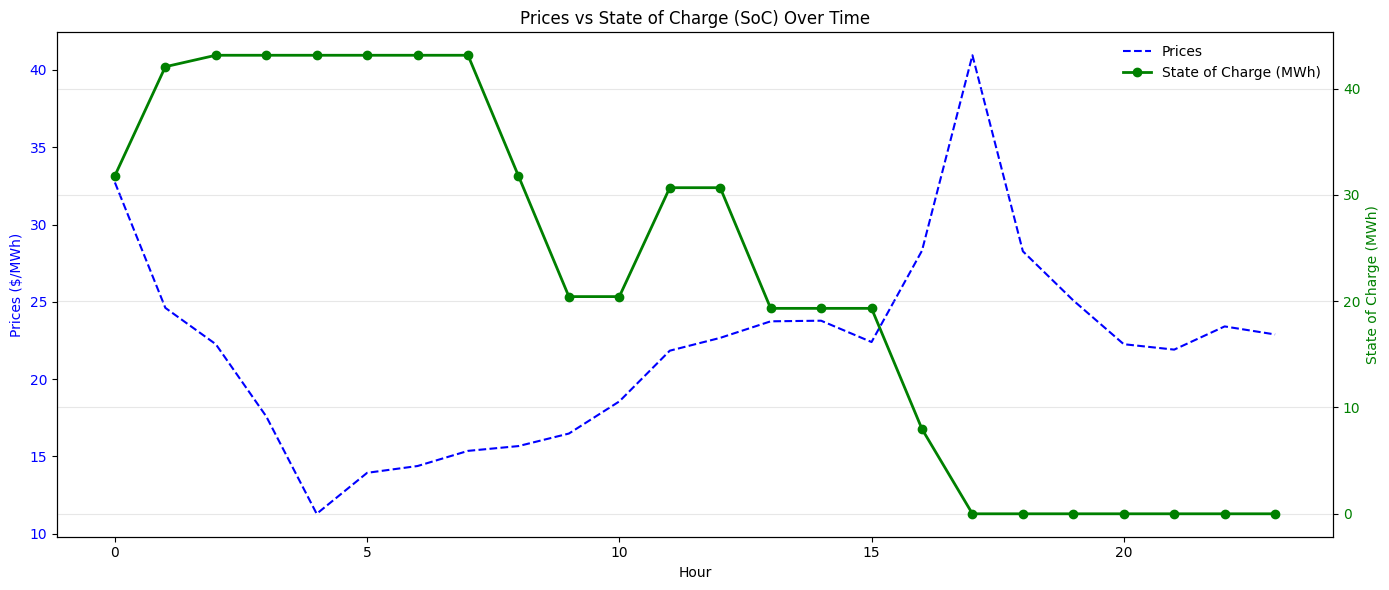

In [13]:
hours = np.arange(24)
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Primary axis (Prices) ---
ax1.plot(hours, day_info_quantile[0].prices_buy, '--b', label='Prices')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Prices ($/MWh)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# --- Secondary axis (State of Charge) ---
ax2 = ax1.twinx()
ax2.plot(hours, np.array(results_quantile[0].soc[1:]) * bat_quantile.capacity_MWh,
         '-og', label='State of Charge (MWh)', linewidth=2, markersize=6)
ax2.set_ylabel('State of Charge (MWh)', color='g')
ax2.tick_params(axis='y', labelcolor='g')


# --- Legends ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best', frameon=False)

plt.title('Prices vs State of Charge (SoC) Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
results_quantile[0].objective_cost, results_time[0].objective_cost

(20568936.951479062, 20568869.076513097)

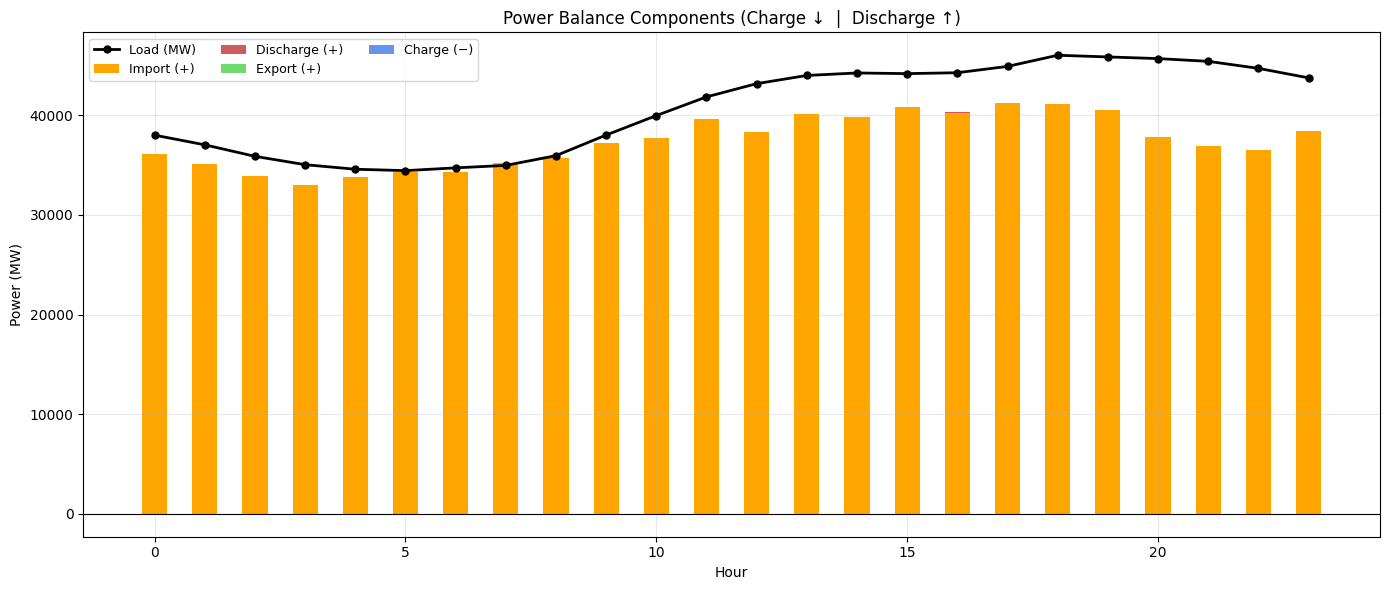

In [15]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.arange(24)

# Data arrays
load = np.array(day_info_quantile[0].demand_MW)
charge = np.array(results_quantile[0].charge_MW)
discharge = np.array(results_quantile[0].discharge_MW)
import_MW = np.array(results_quantile[0].import_MW)
export_MW = np.array(results_quantile[0].export_MW) if getattr(day_info_quantile[0], "allow_export", False) else np.zeros_like(load)

# Flip battery convention for visualization
charge_vis = -charge       # show charge below 0
discharge_vis = discharge  # show discharge above 0

# ---------------------- PLOT ----------------------
fig, ax = plt.subplots(figsize=(14, 6))

# --- positive side stacking (Import + Discharge + Export) ---
# import is base layer
ax.bar(hours, import_MW, width=0.5, color='orange', label='Import (+)')
# discharge stacked on top of import
ax.bar(hours, discharge_vis, width=0.5, bottom=import_MW, color='indianred', label='Discharge (+)')
# export stacked on top (for clear separation)
ax.bar(hours, export_MW, width=0.5, bottom=import_MW + discharge_vis, color='limegreen', alpha=0.7, label='Export (+)')

# --- negative side stacking (Charge only) ---
ax.bar(hours, charge_vis, width=0.5, color='cornflowerblue', label='Charge (−)')

# --- Load as line ---
ax.plot(hours, load, '-ok', linewidth=2, markersize=5, label='Load (MW)')

# Formatting
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Power (MW)")
ax.set_xlabel("Hour")
ax.set_title("Power Balance Components (Charge ↓  |  Discharge ↑)")
ax.legend(ncol=3, loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
len(results_quantile[0].soc[:])

25

In [17]:
# help me create a dataframe to csv to store the results from eval_requests and outputs 
# I wannt to store each row as an hour of a day so explode the day and store each hour in a single row and stack all the days together to form the dataframe.
import pandas as pd
eval_data = {
    "prices_actual": [],
    "prices_forecast": [],
    "actual_demand": [],
    "forecast_demand": [],
    "soc": [],  # exclude final SOC which is after last action
    "charge_MW": [],
    "discharge_MW": [],
    "import_MW": [],
    "export_MW": [],
}

for eval_req, output, in zip(day_info_quantile, results_quantile):
    eval_data["prices_actual"]+= list(eval_req.prices_buy)
    eval_data["prices_forecast"]+= list(eval_req.prices_buy_forecast)
    eval_data["actual_demand"]+= list(eval_req.demand_MW)
    eval_data["forecast_demand"]+= list(eval_req.demand_MW_forecast)
    eval_data["soc"]+= list(output.soc[:-1])
    eval_data["charge_MW"]+= list(output.charge_MW)
    eval_data["discharge_MW"]+= list(output.discharge_MW)
    eval_data["import_MW"]+= list(output.import_MW)
    eval_data["export_MW"]+= list(output.export_MW)
eval_df = pd.DataFrame(eval_data)
eval_df.head()

,prices_actual,prices_forecast,actual_demand,forecast_demand,soc,charge_MW,discharge_MW,import_MW,export_MW
0,32.72,13.907385,38006.938896,36124.576863,0.5000,10.7825,0.0,36135.359363,0.0
1,24.61,14.636284,37036.522365,35113.525930,0.7375,10.7825,0.0,35124.308430,0.0
2,22.26,13.119385,35881.607998,33856.648682,0.9750,1.1350,0.0,33857.783682,0.0
3,17.59,14.734000,35044.055105,33033.047373,1.0000,0.0000,0.0,33033.047373,0.0
4,11.29,12.850335,34585.571140,33756.953375,1.0000,0.0000,0.0,33756.953375,0.0


In [18]:
eval_df["profit_step"] = (eval_df["discharge_MW"] - eval_df["charge_MW"]) * eval_df["prices_actual"] * 1
total_profit = eval_df["profit_step"].sum()

print("Total arbitrage profit:", total_profit)

Total arbitrage profit: 816600.4269564406


In [19]:
eval_df.to_csv(f"HeurQuantile_{data_version}_{forecast_type}_one_year_{REGION}_{YEAR}.csv", index = False)

In [20]:
# help me create a dataframe to csv to store the results from eval_requests and outputs 
# I wannt to store each row as an hour of a day so explode the day and store each hour in a single row and stack all the days together to form the dataframe.
import pandas as pd
eval_data = {
    "prices_actual": [],
    "prices_forecast": [],
    "actual_demand": [],
    "forecast_demand": [],
    "soc": [],  # exclude final SOC which is after last action
    "charge_MW": [],
    "discharge_MW": [],
    "import_MW": [],
    "export_MW": [],
}

for eval_req, output, in zip(day_info_time, results_time):
    eval_data["prices_actual"]+= list(eval_req.prices_buy)
    eval_data["prices_forecast"]+= list(eval_req.prices_buy_forecast)
    eval_data["actual_demand"]+= list(eval_req.demand_MW)
    eval_data["forecast_demand"]+= list(eval_req.demand_MW_forecast)
    eval_data["soc"]+= list(output.soc[1:])
    eval_data["charge_MW"]+= list(output.charge_MW)
    eval_data["discharge_MW"]+= list(output.discharge_MW)
    eval_data["import_MW"]+= list(output.import_MW)
    eval_data["export_MW"]+= list(output.export_MW)
eval_df = pd.DataFrame(eval_data)
eval_df.head()

,prices_actual,prices_forecast,actual_demand,forecast_demand,soc,charge_MW,discharge_MW,import_MW,export_MW
0,32.72,13.907385,38006.938896,36124.576863,2.368421e-01,0.0000,10.78250,36113.794363,0.0
1,24.61,14.636284,37036.522365,35113.525930,2.775558e-17,0.0000,9.70425,35103.821680,0.0
2,22.26,13.119385,35881.607998,33856.648682,2.375000e-01,10.7825,0.00000,33867.431182,0.0
3,17.59,14.734000,35044.055105,33033.047373,4.750000e-01,10.7825,0.00000,33043.829873,0.0
4,11.29,12.850335,34585.571140,33756.953375,7.125000e-01,10.7825,0.00000,33767.735875,0.0


In [21]:
eval_df["profit_step"] = (eval_df["discharge_MW"] - eval_df["charge_MW"]) * eval_df["prices_actual"] * 1
total_profit = eval_df["profit_step"].sum()

print("Total arbitrage profit:", total_profit)

Total arbitrage profit: 491679.8946601245


In [22]:
eval_df.to_csv(f"HeurTime_{data_version}_{forecast_type}_one_year_{REGION}_{YEAR}.csv", index = False)